In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import sys; sys.path.insert(0, '..')
from utils import parse_latencies, parse_power_log

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_model_loading')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4183159.827369208


## Resnet18

In this section, we will analyse the power consumption of Resnet18 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [4]:
model_name = 'resnet18'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
resnet18_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
resnet18_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/'resnet18_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
resnet18_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 60.81it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(resnet18_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(resnet18_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(resnet18_latency_data)}")

Number of power entries for resnet18: 2407617
Number of TensorRT layers in resnet18: 26
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

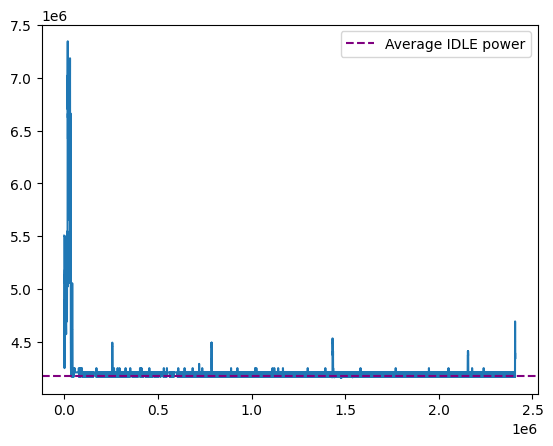

In [6]:
plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [7]:
from utils import plot_inference_cycle_power

In [8]:
def get_power_index(power_data, timestamp):
    index = 0
    while True:
        power_timestamp = power_data[index][0]
        if power_timestamp > timestamp:
            return index
        index += 1

In [9]:
experiment_start_time = datetime.strptime(resnet18_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(resnet18_power_data, experiment_start_time)

model_load_start_time = datetime.strptime(resnet18_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(resnet18_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(resnet18_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(resnet18_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(resnet18_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(resnet18_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(resnet18_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(resnet18_power_data, warmup_end_time)

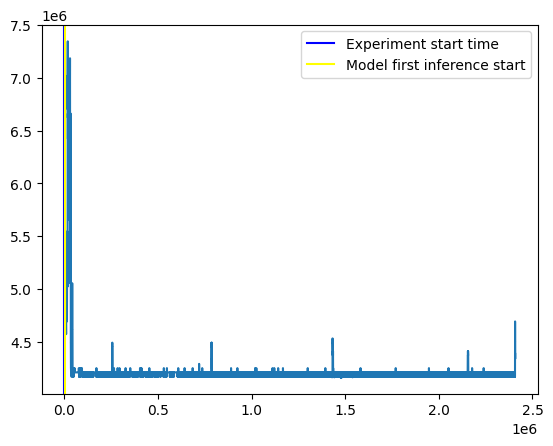

In [10]:
plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(model_load_start_index, color='yellow', label='Model first inference start')
plt.legend()

### Observations

We will be looking at the intial spike in the power profile and breaking it down to understand what is happening in that phase.

We will capture timestamp when the 
- experiment has started
- model is being compiled and add a delay for 10 seconds
- when the warmup is being ran

The above timestamps will provide insights into what is going on with the initial timestamp.

The following plot shows the power profile when the experiment started and before the model is being compiled from PyTorch to TensorRT.

- The experiment starts at a higher power value which slowly decreases and increases.

TODO: We can break down this even more. I will run an experiment to collect data to understand what is happening better.

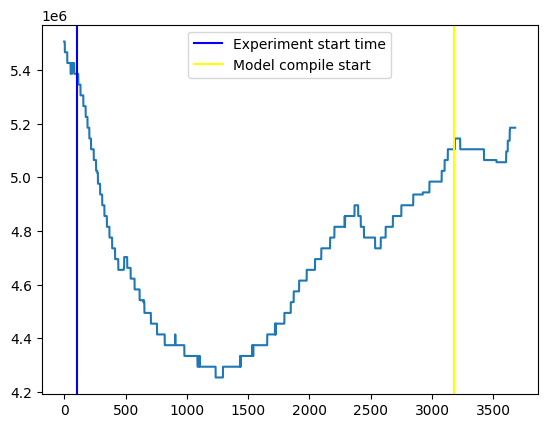

In [11]:
plt.plot(range(0, model_load_start_index+500), [power for (timestamp, power) in resnet18_power_data[:model_load_start_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.legend()

This is the most interesting plot that shows all the things happening before the actual inference starts.

1. Load the PyTorch model and peparate it for converting it to TensorRT. -> **This is the part between blue and yellow line.**
2. Convert the PyTorch model to TensorRT model. -> **This is the part between yellow and red line**.
3. A delay of 10 seconds is added as a cooldown from compilation. -> **This is the part between red and green line**.
4. A warmup of 100 runs is pretty fast. -> **This is the part between green and purple line**. It is fast so the lines are overlapping.

In the following section we break down the actual time taken by these processes as well.

We can also get the power consumed when the model is loaded which is 3rd part above between red and green line.
We get that power value to be `4213440.0`.

So we have power value 

- When jeston is idle : 4183159
- When TRT model is loaded: 4213440
- When inference is ran for 3000 runs: 4213440

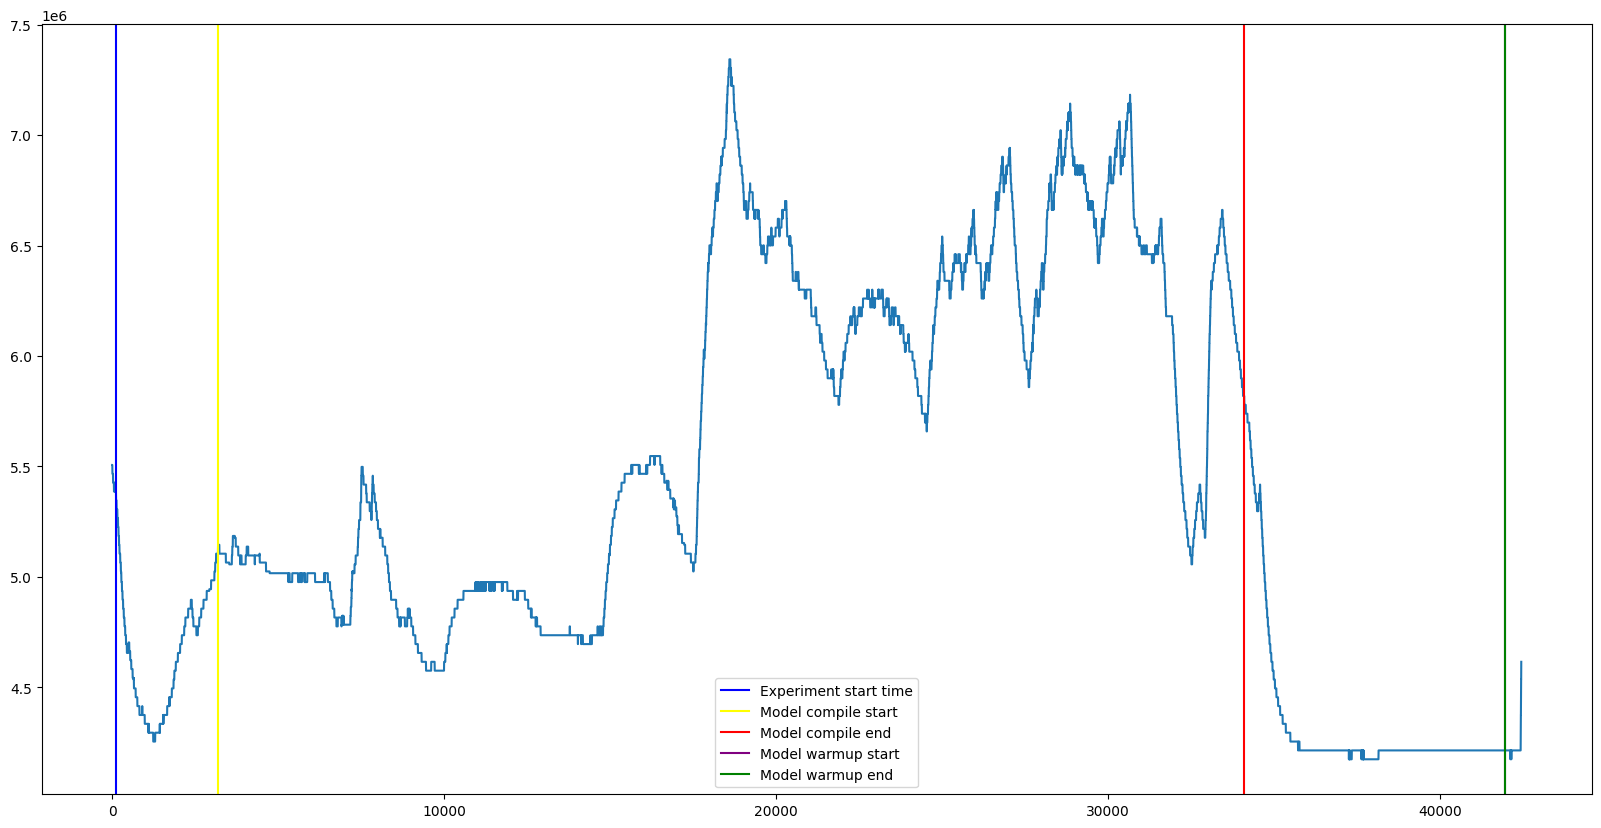

In [12]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in resnet18_power_data[:warmup_end_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.axvline(model_load_end_index, color='red', label='Model compile end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

In [13]:
print(f'Time taken to before the model compile starts: {(model_load_start_time - experiment_start_time).total_seconds()} seconds')
print(f'Time taken to compile the model: {(model_load_end_time - model_load_start_time).total_seconds()} seconds')
print(f'Sleep interval before the warmup: {(warmup_start_time - model_load_end_time).total_seconds()} seconds')
print(f'Time taken to run 100 runs of the warmup: {(warmup_end_time - warmup_start_time).total_seconds()} seconds')

Time taken to before the model compile starts: 4.0 seconds
Time taken to compile the model: 40.0 seconds
Sleep interval before the warmup: 10.0 seconds
Time taken to run 100 runs of the warmup: 0.0 seconds


Something else that is interesting is now the first cylce like the rest of the cycles has similar power profile for the inference.

By adding sufficient delays and allowing the power to cool down, we see that inference for 3000 runs consumes the same power for all cycles. 

> **The power consumed when the inference starts, inference ends and when the delay of 1 second is completed is same for the majority of the runs.**

2025-01-21 15:09:29.673719 -> 2025-01-21 15:09:29.674786
2025-01-21 15:09:30.674786
Time taken by inference cycle 0: 0:00:00.001067
Iteration: 0, Power index: 50306 -> 50308
51090


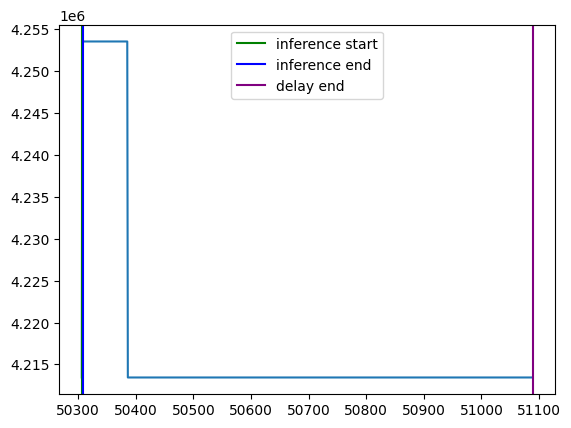

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:30.677698 -> 2025-01-21 15:09:30.678696
2025-01-21 15:09:31.678696
Time taken by inference cycle 1: 0:00:00.000998
Iteration: 1, Power index: 51092 -> 51092
51875


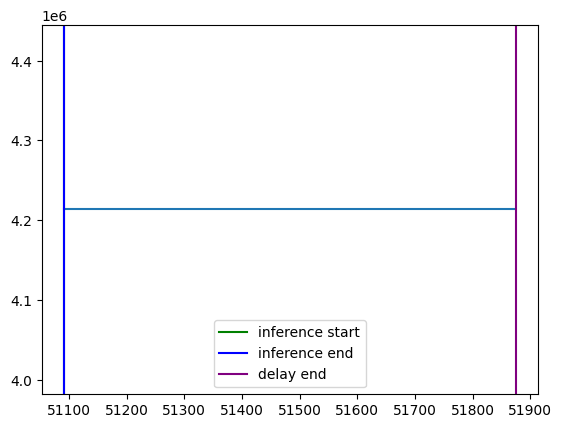

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:31.681390 -> 2025-01-21 15:09:31.682386
2025-01-21 15:09:32.682386
Time taken by inference cycle 2: 0:00:00.000996
Iteration: 2, Power index: 51877 -> 51877
52661


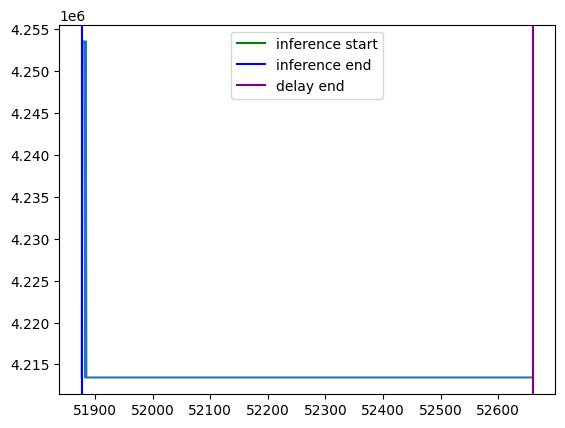

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:32.685001 -> 2025-01-21 15:09:32.685992
2025-01-21 15:09:33.685992
Time taken by inference cycle 3: 0:00:00.000991
Iteration: 3, Power index: 52662 -> 52664
53446


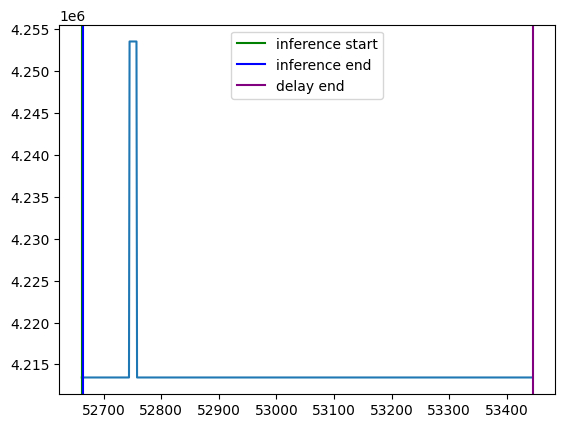

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:33.688218 -> 2025-01-21 15:09:33.689217
2025-01-21 15:09:34.689217
Time taken by inference cycle 4: 0:00:00.000999
Iteration: 4, Power index: 53447 -> 53449
54231


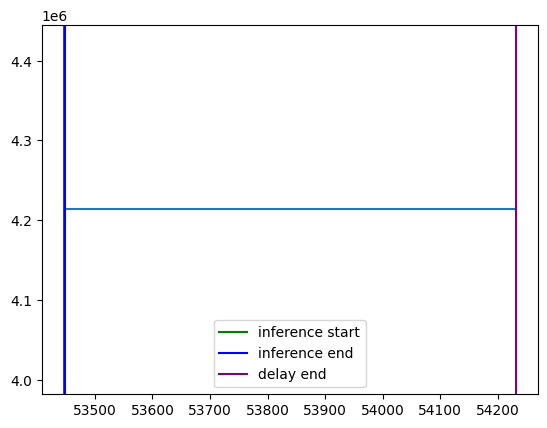

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:34.691877 -> 2025-01-21 15:09:34.692861
2025-01-21 15:09:35.692861
Time taken by inference cycle 5: 0:00:00.000984
Iteration: 5, Power index: 54232 -> 54234
55016


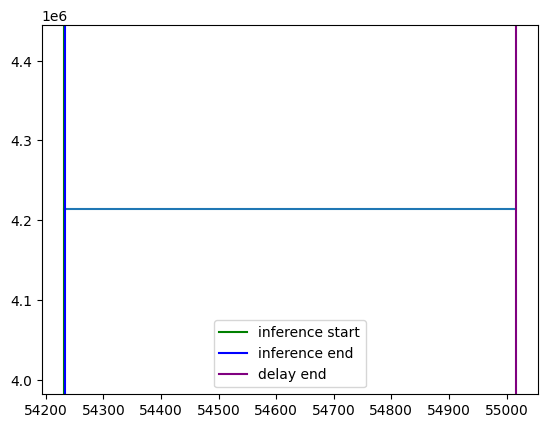

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:35.695538 -> 2025-01-21 15:09:35.696527
2025-01-21 15:09:36.696527
Time taken by inference cycle 6: 0:00:00.000989
Iteration: 6, Power index: 55017 -> 55019
55801


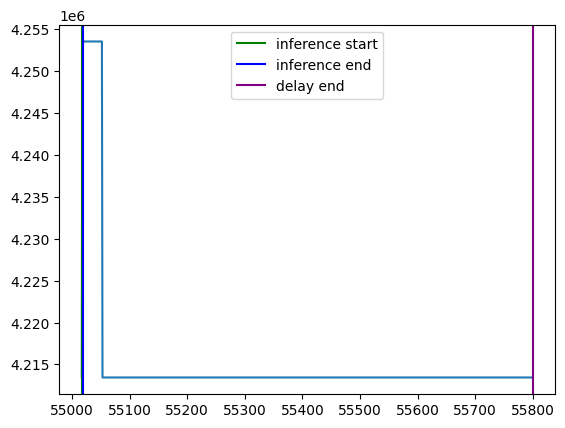

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:36.699178 -> 2025-01-21 15:09:36.700155
2025-01-21 15:09:37.700155
Time taken by inference cycle 7: 0:00:00.000977
Iteration: 7, Power index: 55802 -> 55804
56586


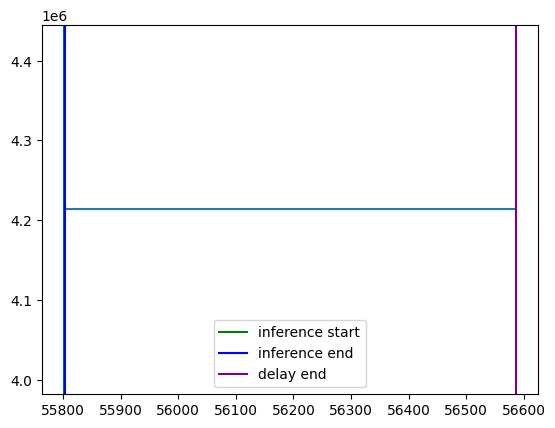

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:37.702798 -> 2025-01-21 15:09:37.703741
2025-01-21 15:09:38.703741
Time taken by inference cycle 8: 0:00:00.000943
Iteration: 8, Power index: 56587 -> 56589
57371


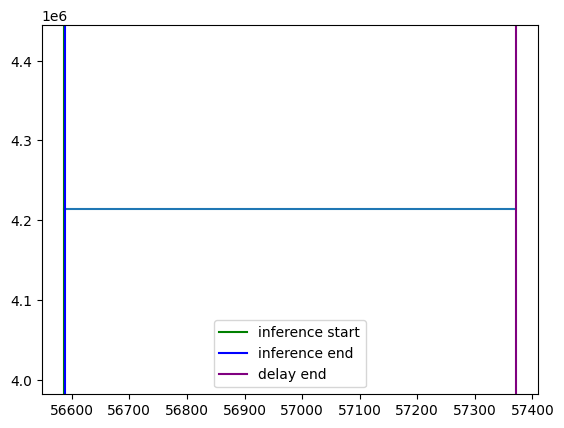

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:38.706311 -> 2025-01-21 15:09:38.707310
2025-01-21 15:09:39.707310
Time taken by inference cycle 9: 0:00:00.000999
Iteration: 9, Power index: 57372 -> 57374
58155


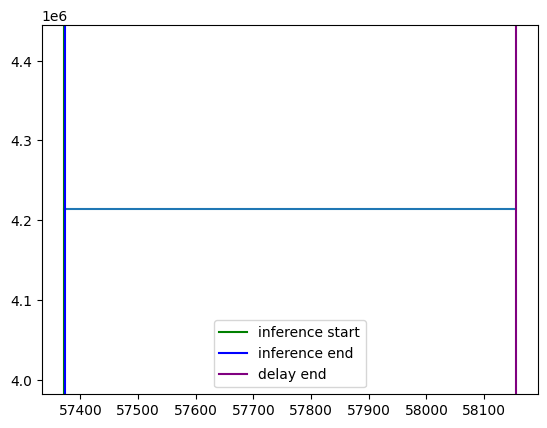

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:39.709889 -> 2025-01-21 15:09:39.710870
2025-01-21 15:09:40.710870
Time taken by inference cycle 10: 0:00:00.000981
Iteration: 10, Power index: 58156 -> 58158
58940


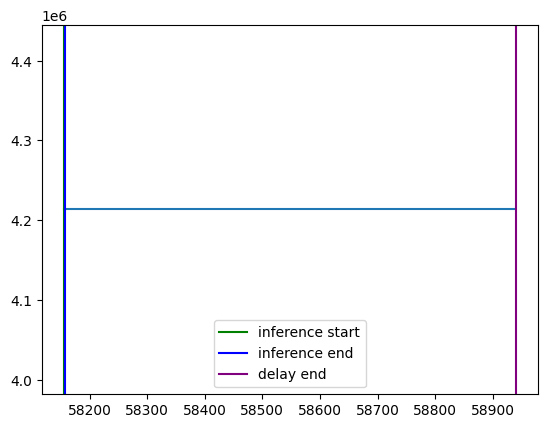

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:40.713432 -> 2025-01-21 15:09:40.714428
2025-01-21 15:09:41.714428
Time taken by inference cycle 11: 0:00:00.000996
Iteration: 11, Power index: 58941 -> 58943
59725


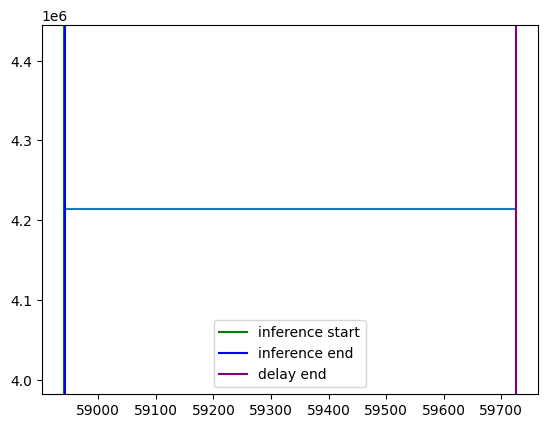

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:41.717022 -> 2025-01-21 15:09:41.718004
2025-01-21 15:09:42.718004
Time taken by inference cycle 12: 0:00:00.000982
Iteration: 12, Power index: 59726 -> 59726
60509


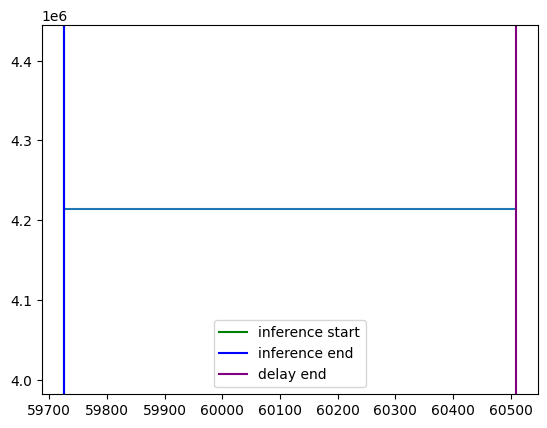

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:42.720559 -> 2025-01-21 15:09:42.721546
2025-01-21 15:09:43.721546
Time taken by inference cycle 13: 0:00:00.000987
Iteration: 13, Power index: 60510 -> 60512
61294


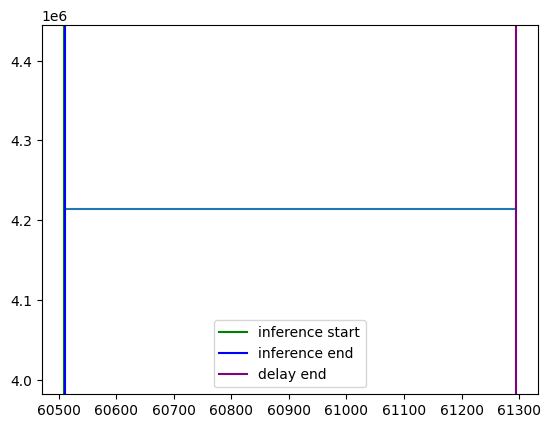

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 15:09:43.724091 -> 2025-01-21 15:09:43.725080
2025-01-21 15:09:44.725080
Time taken by inference cycle 14: 0:00:00.000989
Iteration: 14, Power index: 61295 -> 61297
62079


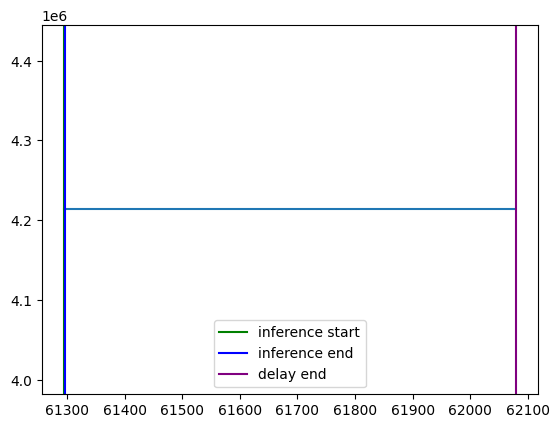

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [14]:
for i in range(15):
    plot_inference_cycle_power(i, resnet18_power_data, resnet18_latency_data, DELAY)